# Robust Binary Classification for Complex Categorical Data
In this work, I tackle the challenge of binary classification on high-cardinality categorical data. Given the complexity introduced by missing values and the risk of overfitting, my focus in this solution is to ensure processing integrity and completely prevent data leakage during training.

Instead of relying on traditional encoding methods, I applied a **Hybrid Feature Engineering** strategy. Safe transformations (such as date features and interactions) are performed globally, while sensitive techniques like **Frequency Encoding** are applied exclusively within **Cross-Validation** loops. This ensures that no information from the test data leaks into the model.

Finally, the model leverages the **CatBoost** algorithm with **GPU acceleration**, allowing for efficient handling of unseen categories and the detection of complex feature interactions to maximize the **AUC** score.

#  Load the datasets and import the library

In [1]:
# --- Setup and Libraries ---
print("--- Step 0: Installing CatBoost Library ---")
!pip install catboost --quiet
print("--- CatBoost installed successfully ---")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from catboost import CatBoostClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import OrdinalEncoder
import warnings

# Display settings and warning suppression
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
pd.set_option('display.max_columns', 100) # To display more columns when printing
print("--- Libraries loaded and settings configured ---")
# --- 1. Quick Look at the Data (Loading Data) ---
print("--- 1. Quick Look at the Data (Loading Data) ---")
BASE_PATH = '/kaggle/input/cat-in-the-dat-ii/'

try:
    train_df = pd.read_csv(BASE_PATH + 'train.csv')
    test_df = pd.read_csv(BASE_PATH + 'test.csv')
except FileNotFoundError:
    print("❌ Error: Make sure to add 'cat-in-the-dat-ii' data to the notebook.")
    raise

# Separate variables
y = train_df['target']
test_ids = test_df['id']
train_df = train_df.drop(['id', 'target'], axis=1)
test_df = test_df.drop('id', axis=1)

print(f"✅ Data loaded successfully.")
print(f"Train data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")

--- Step 0: Installing CatBoost Library ---
--- CatBoost installed successfully ---
--- Libraries loaded and settings configured ---
--- 1. Quick Look at the Data (Loading Data) ---
✅ Data loaded successfully.
Train data shape: (600000, 23)
Test data shape: (400000, 23)


# Quick look at the data

In [2]:
print("First 5 rows of the training data:")
train_df.head()

First 5 rows of the training data:


,bin_0,bin_1,bin_2,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,nom_5,nom_6,nom_7,nom_8,nom_9,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,day,month
0,0.0,0.0,0.0,F,N,Red,Trapezoid,Hamster,Russia,Bassoon,de4c57ee2,a64bc7ddf,598080a91,0256c7a4b,02e7c8990,3.0,Contributor,Hot,c,U,Pw,6.0,3.0
1,1.0,1.0,0.0,F,Y,Red,Star,Axolotl,NaN,Theremin,2bb3c3e5c,3a3a936e8,1dddb8473,52ead350c,f37df64af,3.0,Grandmaster,Warm,e,X,pE,7.0,7.0
2,0.0,1.0,0.0,F,N,Red,NaN,Hamster,Canada,Bassoon,b574c9841,708248125,5ddc9a726,745b909d1,NaN,3.0,NaN,Freezing,n,P,eN,5.0,9.0
3,NaN,0.0,0.0,F,N,Red,Circle,Hamster,Finland,Theremin,673bdf1f6,23edb8da3,3a33ef960,bdaa56dd1,f9d456e57,1.0,Novice,Lava Hot,a,C,NaN,3.0,3.0
4,0.0,NaN,0.0,T,N,Red,Triangle,Hamster,Costa Rica,NaN,777d1ac2c,3a7975e46,bc9cc2a94,NaN,c5361037c,3.0,Grandmaster,Cold,h,C,OZ,5.0,12.0


In [3]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600000 entries, 0 to 599999
Data columns (total 23 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   bin_0   582106 non-null  float64
 1   bin_1   581997 non-null  float64
 2   bin_2   582070 non-null  float64
 3   bin_3   581986 non-null  object 
 4   bin_4   581953 non-null  object 
 5   nom_0   581748 non-null  object 
 6   nom_1   581844 non-null  object 
 7   nom_2   581965 non-null  object 
 8   nom_3   581879 non-null  object 
 9   nom_4   581965 non-null  object 
 10  nom_5   582222 non-null  object 
 11  nom_6   581869 non-null  object 
 12  nom_7   581997 non-null  object 
 13  nom_8   582245 non-null  object 
 14  nom_9   581927 non-null  object 
 15  ord_0   581712 non-null  float64
 16  ord_1   581959 non-null  object 
 17  ord_2   581925 non-null  object 
 18  ord_3   582084 non-null  object 
 19  ord_4   582070 non-null  object 
 20  ord_5   582287 non-null  object 
 21  day     58

In [4]:
train_df.describe()

,bin_0,bin_1,bin_2,ord_0,day,month
count,582106.000000,581997.000000,582070.000000,581712.000000,582048.000000,582012.000000
mean,0.092301,0.185532,0.278704,1.948224,4.112767,6.371317
std,0.289451,0.388729,0.448362,0.853904,2.034430,3.458959
min,0.000000,0.000000,0.000000,1.000000,1.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,2.000000,3.000000
50%,0.000000,0.000000,0.000000,2.000000,5.000000,6.000000
75%,0.000000,0.000000,1.000000,3.000000,6.000000,8.000000
max,1.000000,1.000000,1.000000,3.000000,7.000000,12.000000


In [5]:
train_df.describe(include='O')

,bin_3,bin_4,nom_0,nom_1,nom_2,nom_3,nom_4,nom_5,nom_6,nom_7,nom_8,nom_9,ord_1,ord_2,ord_3,ord_4,ord_5
count,581986,581953,581748,581844,581965,581879,581965,582222,581869,581997,582245,581927,581959,581925,582084,582070,582287
unique,2,2,3,6,6,6,4,1220,1519,222,222,2218,5,6,15,26,190
top,F,N,Red,Triangle,Hamster,India,Theremin,fc8fc7e56,ea8c5e181,4ae48e857,7d7c02c57,8f3276a6e,Novice,Freezing,n,N,Fl
freq,366212,312344,323286,164190,164897,164869,308621,977,805,5035,5052,565,160597,142726,70982,39978,10562


In [6]:
train_df.isnull().sum()

bin_0    17894
bin_1    18003
bin_2    17930
bin_3    18014
bin_4    18047
nom_0    18252
nom_1    18156
nom_2    18035
nom_3    18121
nom_4    18035
nom_5    17778
nom_6    18131
nom_7    18003
nom_8    17755
nom_9    18073
ord_0    18288
ord_1    18041
ord_2    18075
ord_3    17916
ord_4    17930
ord_5    17713
day      17952
month    17988
dtype: int64

In [7]:
train_df.duplicated().sum()

0

#  EDA (Exploratory Data Analysis)

--- Target (y) Distribution Counts ---
target
0    487677
1    112323
Name: count, dtype: int64

--- Target Class Percentage ---
target
0    81.28%
1    18.72%
Name: count, dtype: object


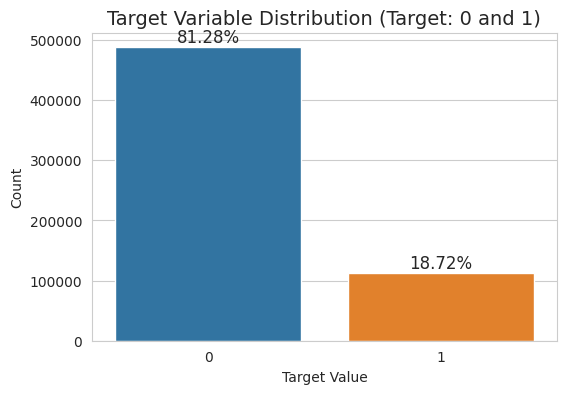

In [8]:
# --- 1. Calculation (Fixes NameError) ---
# Calculate the absolute counts of each target class (0 and 1)
target_counts = y.value_counts()
total_count = len(y)
# Calculate the percentage distribution
target_percentage = (target_counts / total_count) * 100

print("--- Target (y) Distribution Counts ---")
print(target_counts)
print("\n--- Target Class Percentage ---")
print(target_percentage.round(2).astype(str) + '%')

# --- 2. Visualization (Countplot) ---
plt.figure(figsize=(6, 4))
# Note: The 'palette' uses distinct colors for clear visualization.
sns.countplot(x=y, palette=['#1f77b4', '#ff7f0e']) 
plt.title('Target Variable Distribution (Target: 0 and 1)', fontsize=14)
plt.xlabel('Target Value')
plt.ylabel('Count')

# Adding the percentage directly above the bars
for i, count in enumerate(target_counts):
    percentage = target_percentage.iloc[i]
    # Placing the text slightly above the bar (count + 1000) for visibility.
    plt.text(i, count + 1000, f'{percentage:.2f}%', 
             ha='center', va='bottom', fontsize=12)

plt.show()

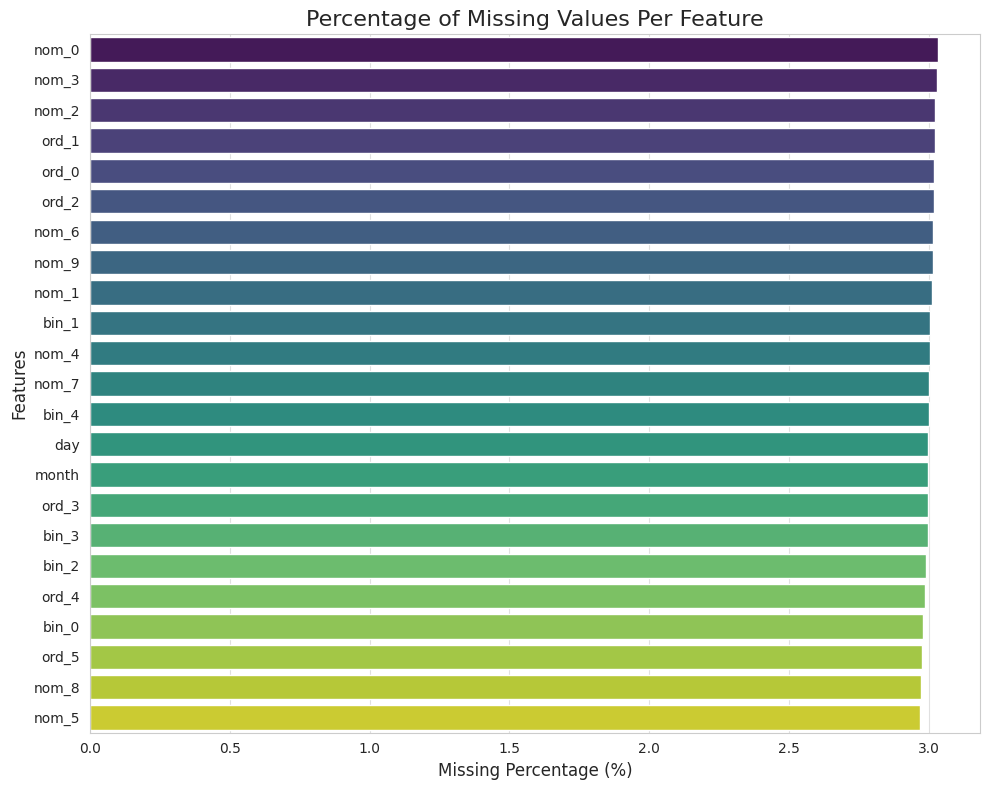


--- Top Missing Features ---
nom_0    3.03%
nom_3    3.03%
nom_2    3.02%
ord_1    3.02%
ord_0    3.02%
ord_2    3.02%
nom_6    3.01%
nom_9    3.01%
nom_1    3.01%
bin_1    3.00%


In [9]:
# --- 1. Data Loading and Initial Setup ---
BASE_PATH = '/kaggle/input/cat-in-the-dat-ii/'

try:
    # Load and drop unnecessary ID/Target columns immediately
    train_df = pd.read_csv(BASE_PATH + 'train.csv').drop(['id', 'target'], axis=1, errors='ignore')
    test_df = pd.read_csv(BASE_PATH + 'test.csv').drop('id', axis=1, errors='ignore')
except FileNotFoundError:
    print("Error: Ensure data is accessible at the specified path.")
    raise

# Concatenate data for combined analysis
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# --- 2. Calculate and Filter Missing Data ---
# Calculate the percentage of missing values for all columns
missing_percentage = full_df.isnull().mean() * 100

# Filter to keep only columns with missing data and sort them
missing_data = missing_percentage[missing_percentage > 0].sort_values(ascending=False)

# --- 3. Visualization and Output ---
if not missing_data.empty:
    plt.figure(figsize=(10, 8))
    
    # Plotting the missing percentage for all relevant features
    sns.barplot(x=missing_data.values, y=missing_data.index, palette="viridis")

    plt.title('Percentage of Missing Values Per Feature', fontsize=16)
    plt.xlabel('Missing Percentage (%)', fontsize=12)
    plt.ylabel('Features', fontsize=12)
    plt.grid(axis='x', alpha=0.6) # Added slight transparency to the grid
    plt.tight_layout()
    plt.show()
    
    print("\n--- Top Missing Features ---")
    # Display the top features and their missing percentage
    print(missing_data.head(10).apply(lambda x: f"{x:.2f}%").to_string())
else:
    print("No missing values found in the combined dataset.")

--- 3. Ordinal Features (ord_2) vs. Target Rate ---


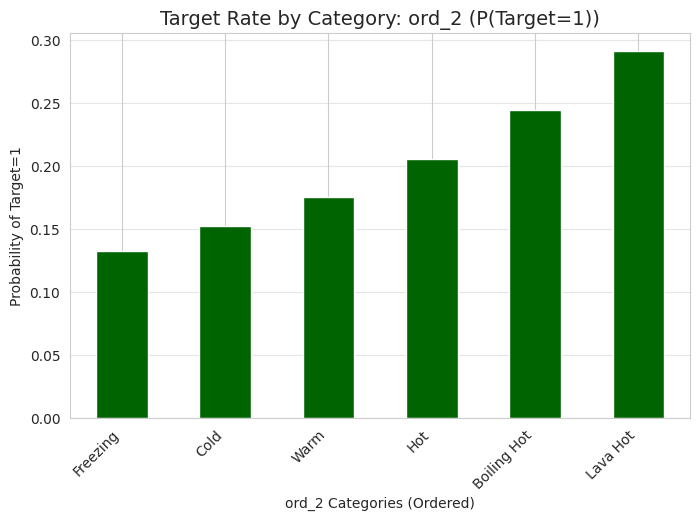

In [10]:
# Assuming 'train_eda' (full original train_df) is available

# Recalculate train_eda just to be safe (if run standalone)
BASE_PATH = '/kaggle/input/cat-in-the-dat-ii/'
train_eda = pd.read_csv(BASE_PATH + 'train.csv')


print("--- 3. Ordinal Features (ord_2) vs. Target Rate ---")

# Calculate P(Target=1) for each category in ord_2
target_rate_ord2 = train_eda.groupby('ord_2')['target'].mean().sort_values()

plt.figure(figsize=(8, 5))
# Plot the mean of the target, which is the probability P(Target=1)
target_rate_ord2.plot(kind='bar', color='darkgreen')
plt.title('Target Rate by Category: ord_2 (P(Target=1))', fontsize=14)
plt.xlabel('ord_2 Categories (Ordered)')
plt.ylabel('Probability of Target=1')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.5)
plt.show()

--- 4. Nominal Feature Cardinality ---


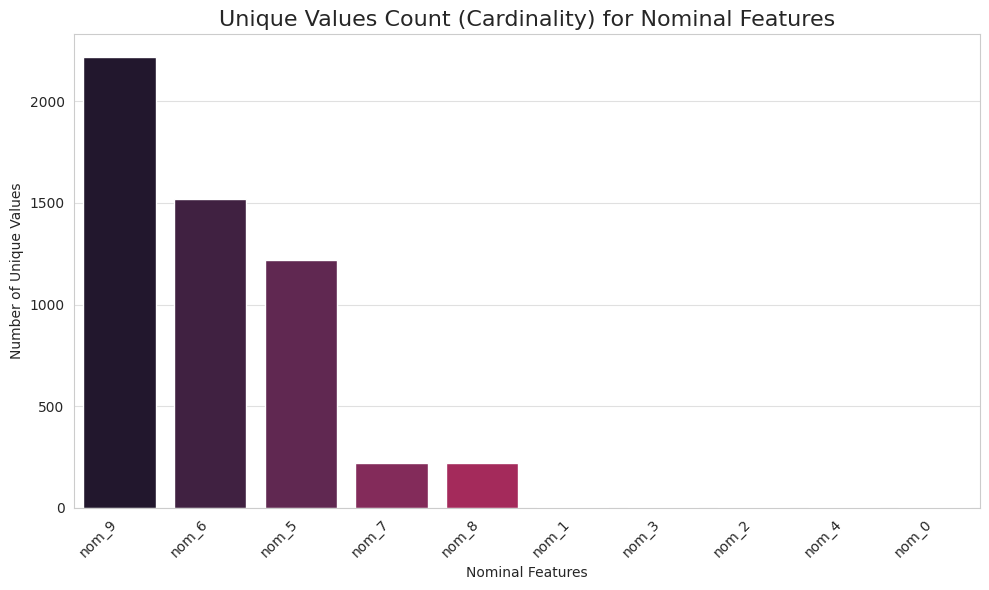

In [11]:
# Assuming 'train_df' is available (features only)

print("--- 4. Nominal Feature Cardinality ---")

# Select only nominal columns for cardinality check
nominal_cols = [col for col in train_df.columns if 'nom_' in col]
cardinality = train_df[nominal_cols].nunique().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=cardinality.index, y=cardinality.values, palette="rocket")
plt.title('Unique Values Count (Cardinality) for Nominal Features', fontsize=16)
plt.xlabel('Nominal Features')
plt.ylabel('Number of Unique Values')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.6)
plt.tight_layout()
plt.show()

--- 5. Cyclical Feature Impact (Monthly Rate) ---


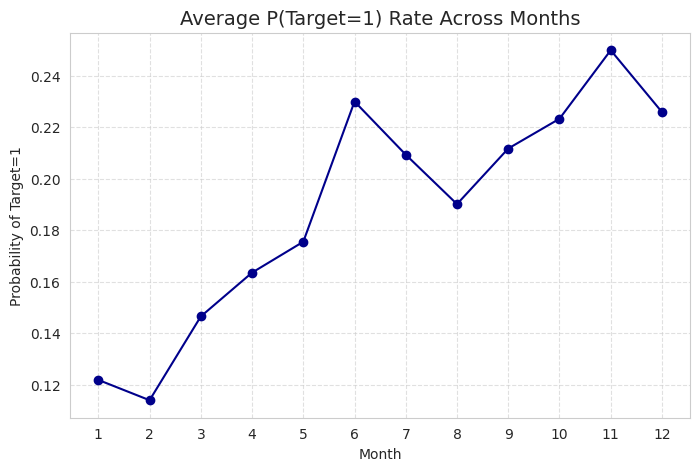

In [12]:
# Assuming 'train_eda' (full original train_df) is available

# Recalculate train_eda just to be safe
BASE_PATH = '/kaggle/input/cat-in-the-dat-ii/'
train_eda = pd.read_csv(BASE_PATH + 'train.csv')


print("--- 5. Cyclical Feature Impact (Monthly Rate) ---")

# Calculate the mean target rate for each month
monthly_target_rate = train_eda.groupby('month')['target'].mean()

plt.figure(figsize=(8, 5))
# Use a line plot to show the cyclical nature
monthly_target_rate.plot(kind='line', marker='o', color='darkblue')
plt.title('Average P(Target=1) Rate Across Months', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Probability of Target=1')
plt.xticks(range(1, 13)) # Ensure all months (1-12) are labeled
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Feature Engineering

In [13]:
# --- 3. Feature Engineering ---
print("\n--- 3. Feature Engineering ---")

# Concatenate data
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)



--- 3. Feature Engineering ---


In [14]:
# 3.1: Handling Missing Values and Creating Indicators
print("--- 3.1: Handling Missing Values and Creating Indicators ---")
for col in full_df.columns:
    if full_df[col].isnull().any():
        full_df[f'{col}_was_missing'] = full_df[col].isnull().astype(int)
        
        if pd.api.types.is_numeric_dtype(full_df[col]):
            full_df[col] = full_df[col].fillna(-1)  
        else:
            full_df[col] = full_df[col].fillna('NONE')

--- 3.1: Handling Missing Values and Creating Indicators ---


In [15]:
# 3.2: Ordinal Feature Encoding (ord_*)
print("--- 3.2: Ordinal Feature Encoding (ord_*) ---")
ord_1_mapping = {'Novice': 1, 'Contributor': 2, 'Expert': 3, 'Master': 4, 'Grandmaster': 5, 'NONE': 0, -1: 0}
ord_2_mapping = {'Freezing': 1, 'Cold': 2, 'Warm': 3, 'Hot': 4, 'Boiling Hot': 5, 'Lava Hot': 6, 'NONE': 0, -1: 0}

full_df['ord_1'] = full_df['ord_1'].map(ord_1_mapping)
full_df['ord_2'] = full_df['ord_2'].map(ord_2_mapping)

ord_3_col = ['ord_3', 'ord_4', 'ord_5']
for col in ord_3_col:
    # Use OrdinalEncoder after filling missing values
    full_df[col] = full_df[col].replace('NONE', chr(ord('a') - 1)).fillna(chr(ord('a') - 1))
    encoder = OrdinalEncoder(categories=[sorted(full_df[col].unique())], dtype=int)
    full_df[col] = encoder.fit_transform(full_df[[col]])

--- 3.2: Ordinal Feature Encoding (ord_*) ---


In [16]:
# 3.3: Frequency Encoding
print("--- 3.3: Frequency Encoding ---")
all_cat_cols = [col for col in full_df.columns if 'nom_' in col or 'bin_' in col or 'day' in col or 'month' in col]
for col in all_cat_cols:
    freq_map = full_df[col].value_counts().to_dict()
    full_df[f'{col}_freq'] = full_df[col].map(freq_map)

--- 3.3: Frequency Encoding ---


In [17]:
# 3.4: Cyclical Feature Engineering
print("--- 3.4: Cyclical Feature Engineering (day, month) ---")
full_df['day_sin'] = np.sin(2 * np.pi * full_df['day'] / 7.0)
full_df['day_cos'] = np.cos(2 * np.pi * full_df['day'] / 7.0)
full_df['month_sin'] = np.sin(2 * np.pi * full_df['month'] / 12.0)
full_df['month_cos'] = np.cos(2 * np.pi * full_df['month'] / 12.0)
full_df = full_df.drop(['day', 'month'], axis=1)


--- 3.4: Cyclical Feature Engineering (day, month) ---


In [18]:
# 3.5: Feature Interactions
print("--- 3.5: Feature Interactions ---")
full_df['ord_1_nom_3'] = full_df['ord_1'].astype(str) + '_' + full_df['nom_3'].astype(str)
full_df['ord_1_ord_2'] = full_df['ord_1'].astype(str) + '_' + full_df['ord_2'].astype(str)


--- 3.5: Feature Interactions ---


In [19]:
# 3.6: Converting Categorical Columns to 'category' (for CatBoost)
print("--- 3.6: Converting Categorical Columns to 'category' ---")
# Ensure bin_x columns are string type before converting to category
binary_cols_to_fix = [col for col in full_df.columns if 'bin_' in col]
for col in binary_cols_to_fix:
    full_df[col] = full_df[col].astype(str)

nominal_cols = [col for col in full_df.columns if 'nom_' in col or 'bin_' in col]
interaction_cols = ['ord_1_nom_3', 'ord_1_ord_2']
for col in nominal_cols + interaction_cols:
    full_df[col] = full_df[col].astype('category')

--- 3.6: Converting Categorical Columns to 'category' ---


In [20]:
# Separate data back
X = full_df.iloc[:len(train_df)]
X_test = full_df.iloc[len(train_df):]

In [21]:
# Define Categorical Columns for CatBoost
categorical_features = [col for col in X.columns if X[col].dtype.name == 'category']
print(f"Total number of features: {len(X.columns)}")
print(f"Number of categorical features for CatBoost: {len(categorical_features)}")
print("--- Feature Engineering completed. ---")

Total number of features: 84
Number of categorical features for CatBoost: 62
--- Feature Engineering completed. ---


# Train ML model

In [22]:
## --- 4. Train ML Model (CatBoost Training) ---
print("\n--- 4. Train ML Model (Training with CatBoost) ---")
print("🔥 Using StratifiedKFold and GPU training (requires GPU environment).")

# CatBoost parameters definition
cat_params = {
    'iterations': 3000,
    'learning_rate': 0.02,
    'depth': 6,
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': 0,
    'early_stopping_rounds': 1000,
    'task_type': 'GPU',     # Modification to enable GPU acceleration
    'metric_period': 20     # Reduce number of output metric prints to minimize slowdown
}

N_SPLITS = 10
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)

oof_preds_cat = np.zeros(len(X))
test_preds_cat = np.zeros(len(X_test))


--- 4. Train ML Model (Training with CatBoost) ---
🔥 Using StratifiedKFold and GPU training (requires GPU environment).


In [23]:
# Training and Cross-Validation loop
for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
  
    print(f"\n--- FOLD {fold + 1}/{N_SPLITS} ---") 
    
    X_train, X_val = X.iloc[train_index], X.iloc[val_index]
    y_train, y_val = y.iloc[train_index], y.iloc[val_index]
    
    model_cat = CatBoostClassifier(**cat_params)
    
    model_cat.fit(X_train, y_train,
                  eval_set=[(X_val, y_val)],
                  cat_features=categorical_features,
                  verbose=0
                  )
    
    val_preds = model_cat.predict_proba(X_val)[:, 1]
    oof_preds_cat[val_index] = val_preds
    test_preds_cat += model_cat.predict_proba(X_test)[:, 1] / N_SPLITS
    
    print(f"Fold {fold + 1} AUC: {roc_auc_score(y_val, val_preds):.6f}")
    
        # The preceding code block calculates val_preds and roc_auc_score
    print(f"Fold {fold+1} AUC: {roc_auc_score(y_val, val_preds)}")
    
 
overall_auc_cat = roc_auc_score(y, oof_preds_cat)
print(f"\n===================================")
print(f"Overall OOF AUC (CatBoost): {overall_auc_cat:.6f}")
print(f"===================================")


--- FOLD 1/10 ---
Fold 1 AUC: 0.786980
Fold 1 AUC: 0.7869800287196171

--- FOLD 2/10 ---
Fold 2 AUC: 0.786811
Fold 2 AUC: 0.786810988205217

--- FOLD 3/10 ---
Fold 3 AUC: 0.789380
Fold 3 AUC: 0.7893803112831215

--- FOLD 4/10 ---
Fold 4 AUC: 0.789318
Fold 4 AUC: 0.789318315399711

--- FOLD 5/10 ---
Fold 5 AUC: 0.786836
Fold 5 AUC: 0.7868363167156689

--- FOLD 6/10 ---
Fold 6 AUC: 0.791920
Fold 6 AUC: 0.7919195519626385

--- FOLD 7/10 ---
Fold 7 AUC: 0.784049
Fold 7 AUC: 0.7840490413854351

--- FOLD 8/10 ---
Fold 8 AUC: 0.789620
Fold 8 AUC: 0.7896195020080979

--- FOLD 9/10 ---
Fold 9 AUC: 0.787170
Fold 9 AUC: 0.7871703422640176

--- FOLD 10/10 ---
Fold 10 AUC: 0.786177
Fold 10 AUC: 0.7861772402431954

Overall OOF AUC (CatBoost): 0.787819


In [24]:
# --- 5. Submission (Creating Submission File) ---
print("\n--- 5. Submission (Creating Submission File) ---")
submission_df_cat = pd.DataFrame({'id': test_ids, 'target': test_preds_cat})
submission_df_cat.to_csv('submission.csv', index=False)

print("✅ 'submission.csv' file created successfully.")


--- 5. Submission (Creating Submission File) ---
✅ 'submission.csv' file created successfully.
